In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker
import math
import pandas as pd
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.colors import ListedColormap

In [2]:
### ----- SET GLOBAL MATPLOTLIB PARAMS -----

dpi = 300

lrgtxt = 11
medtxt = 9
smltxt = 7

plt.rcParams['xtick.labelsize']=smltxt
plt.rcParams['ytick.labelsize']=smltxt

plt.rcParams['axes.titlesize']=lrgtxt
plt.rcParams['axes.labelsize']=medtxt
plt.rcParams["axes.titlepad"]=12
plt.rcParams['axes.linewidth']=1
plt.rcParams["axes.spines.right"]=False
plt.rcParams["axes.spines.top"]=False

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.rcParams['svg.fonttype'] = 'none'

plt.rcParams['savefig.dpi'] = dpi
plt.rcParams['figure.dpi']= dpi
plt.rcParams['figure.constrained_layout.use'] = True

plt.rcParams['savefig.transparent'] = True

# colors
acols = [[0.627451,   0.57254905, 0.37254903], # all colors
    [0.9607843,  0.7882353,  0.15294118],
    # [0.34901962, 0.35686275, 0.49019608],
    [0.19140625, 0.1953125, 0.265625],
    [0.24705882, 0.30588236, 0.9607843 ]]

fcols = acols[0:2] # female colors, WT first
mcols = acols[2:] # male colors, WT first

# whisker dimensions
whiskspacer = 0.15
whiskpos = -whiskspacer

# plotting parameters
medlw = 1.5 # median linewidth
boxalpha = 0.5 # transparency for boxplot face color
caps = False # don't put caps on the error bars
bwidth = 0.9 # box width
ppad = 0.0085*2 # size of pvalue offset and height of bracket legs
plw = 0.8 # line thickness for pvalue bracket
dotsz = 5

# stats parameters
palpha = 0.05

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# set labels
xlab = ''
ylab = 'percent of assay'
lbls = ['+/+','-/+']

# stats display parameters
pvpct = 0.2

# output directory for figure files
# outdir = 'M:\\scn2a-paper-GWJSNH\\manuscript_v2\\figure_panels'
outdir = 'C:\\Users\\nhogl\\Documents\\Manoli Lab\\2026_scn2a_manuscript\\figure_panels'

# save figures?
savefigs = True

# print stats?
printstats = True

In [3]:
# ----- LOAD DATA -----
data_orig = pd.read_csv(os.path.join('..','all_annotations.csv')).drop(labels=['Unnamed: 0','id'],axis=1)

In [4]:
# ----- FILTER DATA -----

# filter to males
sex = 'M'
data = data_orig[data_orig.sex==sex].copy().reset_index(drop=True)

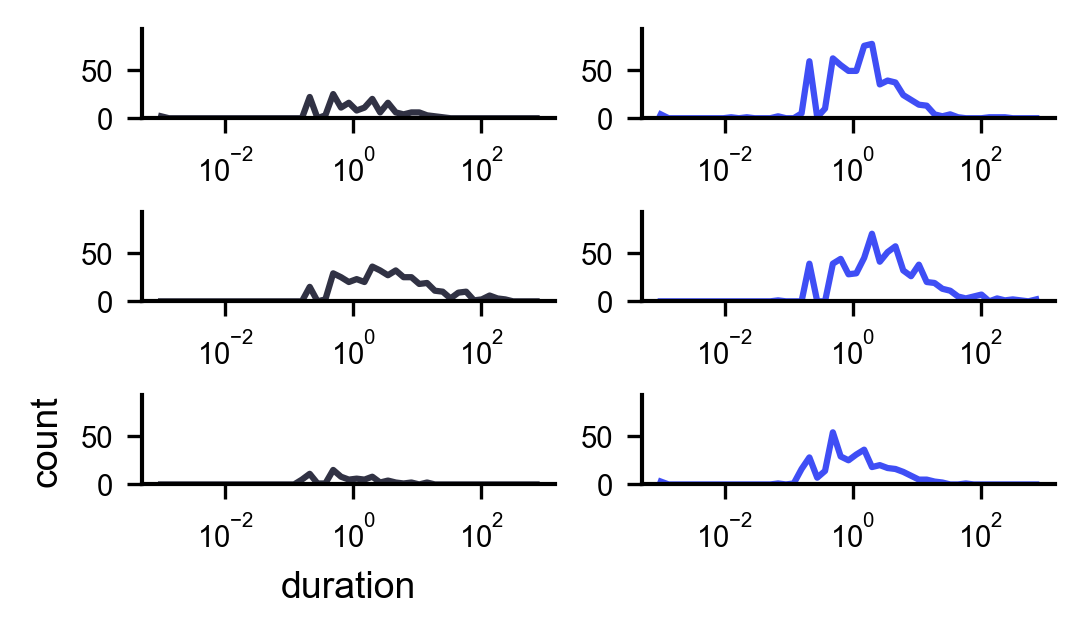

In [46]:
# ----- DISTRIBUTIONS OF HUDDLE LENGTH -----

assays = ['introduction','reunion','aggression']
gts = ['WT','Het']
assaydurs = [1800,1800,1200]
meta = ['sex','GT','pair_tag']
behavs = ['Investigate','Sniff','Huddle']
blist = [behavs[2]]
bdat = data[data['behavior']==blist[0]].copy().reset_index(drop=True)
sdat = bdat[bdat.duration>0].copy().reset_index(drop=True)
minval = np.min(sdat.duration)
maxval = np.max(sdat.duration)
bins = np.logspace(np.log10(minval),np.log10(maxval),50)
hists = []

# make figure
figsz = (3.5,2) # total size of figure
fig, axs = plt.subplots(3,2,figsize=figsz)

mxbin = 0

for i,gt in enumerate(gts):
    gdf = sdat[sdat['GT']==gt].copy().reset_index(drop=True)
    tcol = mcols[i]
    for j,assay in enumerate(assays):
        adf = gdf[gdf['assay']==assay].copy().reset_index(drop=True)
        thist,rebins = np.histogram(adf['duration'],bins=bins)
        hists.append(thist)
        ax = axs[j,i]
        ax.plot(bins[0:-1],thist,color=tcol)
        ax.set_xscale('log')
        mxbin = np.max([np.max(thist),mxbin])
        if j==2:
            if i==0:
                ax.set_xlabel('duration')
                ax.set_ylabel('count')

for i,gt in enumerate(gts):
    for j,assay in enumerate(assays):
        ax = axs[j,i]
        ax.set_ylim([0,mxbin*1.2])

In [6]:
# ----- DEFINE FUNCTIONS -----

def testNormal(input, alpha=0.05):
    if len(input) >= 20:
        #This function is based on D’Agostino and Pearson’s test that combines skew and kurtosis to produce an omnibus test of normality
        results = scipy.stats.normaltest(input) 
        p_values = results.pvalue
        normal_method = "D'Agostino-Pearson test (combined kurtosis + skewness)"
        if p_value > alpha: isnormal = True
        elif p_value <= alpha: isnormal = False
    else: 
        #For n<20, we have to rely on a Monte Carlo approach to test skew and kurtosis (kurtosistest is only valid n>=20) 
        rvs = lambda size: scipy.stats.norm.rvs(size=size, random_state=np.random.default_rng())
        skew_results = scipy.stats.monte_carlo_test(input, rvs, scipy.stats.skew, vectorized=True)
        kurtosis_results = scipy.stats.monte_carlo_test(input, rvs, scipy.stats.kurtosis, vectorized=True)
        p_values = [skew_results.pvalue, kurtosis_results.pvalue]
        normal_method = "Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)"
        # data is only treated as normal if it has both normal skew and kurtosis
        if p_values[0] > 0.05 and p_values[1] > alpha: isnormal = True
        else: isnormal = False
    return isnormal, p_values, normal_method

def decide_pval_text(pval,palpha):

    if palpha<pval<palpha+0.015:
        ptxt = f'p = {pval:.2f}'
    elif pval>palpha:
        ptxt = 'n.s.'
    elif palpha/50<pval<palpha:
        ptxt='*'
    elif palpha/500<pval<palpha/50:
        ptxt ='**'
    elif palpha/5000<pval<palpha/500:
        ptxt = '***'
    else:
        ptxt = '****'
    
    return ptxt

def add_pair_to_plot_box(df,grp1,grp2,statkey,zeros,ax,ax2,col1,col2,startx,dotdist,errdist,psdist,whiskpos,ptxt,hatch):

    # -- GROUP 1 --
    tdf = df[df['GT']==grp1].copy().reset_index(drop=True)
    tcol=col1

    max1 = np.max(tdf[statkey])
    min1 = np.min(tdf[statkey])
    
    # plot group 1 dots
    ax.plot(np.zeros(tdf.shape[0])+startx+dotdist, tdf[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha = 1)
    
    # plot group 1 boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)

    bplot = ax.boxplot(tdf[statkey],positions=[startx],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)

    for box in bplot['boxes']:
        box.set(hatch=hatch,fill=True)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(tdf[statkey],positions=[startx+whiskpos],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)

    t0 = zeros[zeros['GT']==grp1].copy().reset_index(drop=True)
    nr0 = t0.shape[0]
    if nr0>0:
        coords0 = np.linspace(startx+dotdist,startx+whiskpos,nr0)
        ax2.plot(coords0, np.zeros(nr0), 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha = 1)


    # -- GROUP 2 --    
    tdf = df[df['GT']==grp2].copy().reset_index(drop=True)
    tcol=col2

    max2 = np.max(tdf[statkey])
    min2 = np.min(tdf[statkey])
    
    # plot stranger dots
    ax.plot(np.zeros(tdf.shape[0])+startx+psdist-dotdist, tdf[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha=1)

    # plot stranger boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)
    bplot = ax.boxplot(tdf[statkey],positions=[startx+psdist],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)

    for box in bplot['boxes']:
        box.set(hatch=hatch,fill=True)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(tdf[statkey],positions=[(startx+psdist-whiskpos)],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)

    t0 = zeros[zeros['GT']==grp2].copy().reset_index(drop=True)
    nr0 = t0.shape[0]
    if nr0>0:
        coords0 = np.linspace(startx+psdist-dotdist,startx+psdist-whiskpos,nr0)
        ax2.plot(coords0, np.zeros(nr0), 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha = 1)

    return np.min([min1,min2]), np.max([max1,max2])

def make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur,hatch):
    # organize and sum total behavior time
    # sums = fdat.groupby(by=['pair_tag','GT','sex']).duration.sum().reset_index()
    eps = 0.0000001
    sums = fdat.copy()
    sums['fraction']=sums['duration']
    # filter out zero values and save them for plotting
    zeroidx = sums['duration']==0
    zeros = sums[zeroidx].copy().reset_index()
    sums = sums[~zeroidx].copy().reset_index()
   
    # keep track of details across multiple plots
    axes = []
    ax2s = []
    maxes = []
    mins = []
    ptxts = []
    figs = []
    fnames = []
    
    # do a loop over sexes to make sure they have the same axis parameters
    for sex in sexes:
        if sex=='male':
            sexlet = 'M'
            cols = mcols
        else:
            sexlet = 'F'
            cols = fcols
    
        fname = f'boxDotPlot_{assay}_duration_{bstr}{sex}.svg' # generate file name for output plot
        print(fname)
        fnames.append(fname)
    
        # filter to given sex
        fsums = sums[sums['sex']==sexlet].copy().reset_index(drop=True)
        fzeros = zeros[zeros['sex']==sexlet].copy().reset_index(drop=True)
    
        # -- stats --
        # log transform data to check for normality
        # check for normality
        # print results of normality check
        isnorms = []
        for gt in ['WT','Het']:
            # isnormal,p_values,normal_method = testNormal(np.log(fsums[fsums['GT']==gt]['duration']))
            shapres = scipy.stats.shapiro(np.log(fsums[fsums['GT']==gt]['duration']))
            p_values = shapres.pvalue
            isnormal = p_values>palpha
            normal_method = 'Shapiro-Wilk test'
            isnorms.append(isnormal)
            print(f'Normality test results for {gt} {sex}: {isnormal} by {normal_method}, p = {p_values}')
        # check whether normal distribution holds
        if all(isnorms):
            # check for equal variance
            bartres = scipy.stats.bartlett(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration']))
            eqvar = bartres.pvalue>0.05
            # run ttest on log transformed data
            statres = scipy.stats.ttest_ind(np.log(fsums[fsums['GT']=='WT']['duration']),np.log(fsums[fsums['GT']=='Het']['duration'])
                                            ,equal_var=eqvar)
        else:
            statres = scipy.stats.mannwhitneyu(fsums[fsums['GT']=='WT']['duration'],fsums[fsums['GT']=='Het']['duration'])
    
        if printstats:
            print(statres) 
        pval = statres.pvalue
        ptxt = decide_pval_text(pval,palpha)
        ptxts.append(ptxt)
    
        # make figure
        figsz = (1.25,2) # total size of figure
        fig, (ax, ax2) = plt.subplots(2,1,sharex=True,figsize=figsz,gridspec_kw={'height_ratios': [10, 1]})
        axes.append(ax)
        ax2s.append(ax2)
        figs.append(fig)
    
        # make plot
        mn,mx = add_pair_to_plot_box(fsums,'WT','Het','fraction',fzeros,ax,ax2,cols[0],cols[1],start,dotdist,errdist,psdist,whiskpos,ptxt,hatch)
        maxes.append(mx)
        mins.append(mn)
        # fig.text(0.64,-0.065,'Scn2a',ha='center',size=lrgtxt)
        # plt.text(0.5,-0.065,'Scn2a',ha='center',size=lrgtxt)

    
    for ax,ptxt,fig,fname,ax2 in zip(axes,ptxts,figs,fnames,ax2s):
        ax.set_yscale('log')
        
        # calculations for scaling min, max, and pval stuff
        tmx = np.max(maxes)
        tmn = np.min(mins)
        axmin = tmn-0.25*tmn
        axmax = 1.75*tmx
        ax.set_ylim([axmin,axmax])
        
        # display statistical test results
        axrange = axmax-axmin
        ppad = axrange*pvpct
        y, h = tmx + ppad, ppad
        px1 = start
        px2 = start+psdist
        ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
        # make height pad factor to pull test bracket up
        ax.text((px1+px2)*.5, y+h+0.3*h, ptxt, ha='center', va='bottom', color='k',size=medtxt)
        
        # labeling
        ax.spines['bottom'].set_visible(False)
        ax2.spines['bottom'].set_visible(False)
        ax2.set_xticks([start,start+psdist],labels=lbls,fontsize=medtxt)
        ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
        ax.get_yaxis().set_minor_formatter(matplotlib.ticker.NullFormatter())
        labels = []
        for tick in ax.get_yticks():
            if tick>=1:
                label = f'{int(tick)}'
            else:
                label = f'{tick: .1f}'
            labels.append(label)
        ax.set_yticklabels(labels)
        ax.tick_params(axis='x', which='both',length=0)
        ax2.tick_params(axis='x', which='both',length=0)
        ax2.set_xlabel(xlab,)
        ax.set_ylabel(ylab)
        ax2.set_ylim([-0.5,0.5])
        ax2.set_yticks([0])

        # add slashes to broken axis
        d = .5  # proportion of vertical to horizontal extent of the slanted line
        kwargs = dict(marker=[(-1, -d), (1, d)], markersize=3,
                      linestyle="none", color='k', mec='k', mew=1, clip_on=False)
        ax.plot([0], [0], transform=ax.transAxes, **kwargs)
        ax2.plot([0], [1.05], transform=ax2.transAxes, **kwargs)

        ax2.set_facecolor([0.9,0.9,0.9])

    
        if savefigs:
            fig.savefig(os.path.join(outdir,fname),bbox_inches='tight')

def make_bins_from_DF(df,stepsize,assaylen):

    allpairs = np.unique(df.pair_tag)
    
    nrsteps = int((assaylen)/stepsize)
    bins = np.linspace(0, assaylen-stepsize, num=nrsteps)
    nrbins = len(bins)

    for j,pair in enumerate(allpairs):
        thisdf = df[df.pair_tag==pair].copy().reset_index(drop=True)
        gt = np.unique(thisdf.GT)[0]
        sex = np.unique(thisdf.sex)[0]
        try:
            pn = np.unique(thisdf.pair_num)[0]
        except:
            pn = np.unique(thisdf.pair)[0]
        thisdf['starts_idx'] = np.round(thisdf.start_time,decimals=1)*10
        thisdf['ends_idx'] = np.round(thisdf.stop_time,decimals=1)*10
        startsl = thisdf.starts_idx.to_list()
        endsl = thisdf.ends_idx.to_list()
        blankbins = np.zeros((len(bins,)))
        for i,start in enumerate(startsl):
            blankbins[int(start):int(endsl[i])] = 1
        GTs = [gt]*nrsteps
        sexes = [sex]*nrsteps
        PTs = [pair]*nrsteps
        pairnr = [pn]*nrsteps
        bindat = {'bins': bins, 'data': blankbins, 'sex':sexes,'GT':GTs,'pair_tag':PTs,'pair_number':pairnr}
        bindf = pd.DataFrame(data=bindat) 

        if j==0:
            collbins = bindf
        else:
            collbins = pd.concat([collbins,bindf])
  
    collbins['raw_cumes'] = collbins.groupby('pair_tag').data.cumsum()/10
    collbins['totals'] = collbins.groupby('pair_tag')['data'].transform('sum')/10
    collbins['cumes_behav_frac'] = collbins.raw_cumes/collbins.totals
        
    return collbins

boxDotPlot_introduction_count_Huddle_female.svg
Normality test results for WT female: True by Shapiro-Wilk test, p = 0.3243082289865124
Normality test results for Het female: True by Shapiro-Wilk test, p = 0.346519132174925
TtestResult(statistic=np.float64(0.8694850058730261), pvalue=np.float64(0.39356552819448243), df=np.float64(23.0))
boxDotPlot_introduction_count_Huddle_male.svg
Normality test results for WT male: False by Shapiro-Wilk test, p = 0.01920519777657192
Normality test results for Het male: True by Shapiro-Wilk test, p = 0.12591037336637861
MannwhitneyuResult(statistic=np.float64(55.0), pvalue=np.float64(0.14268048429722283))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


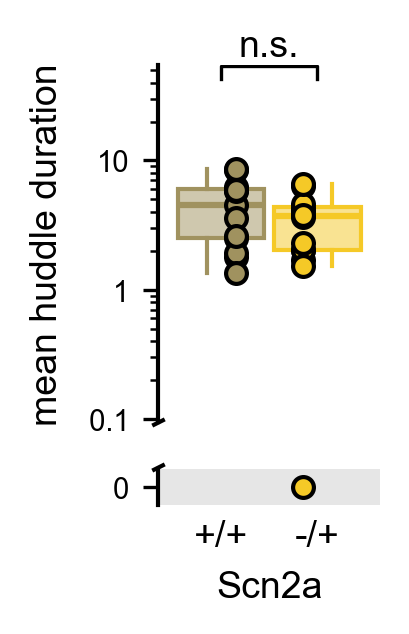

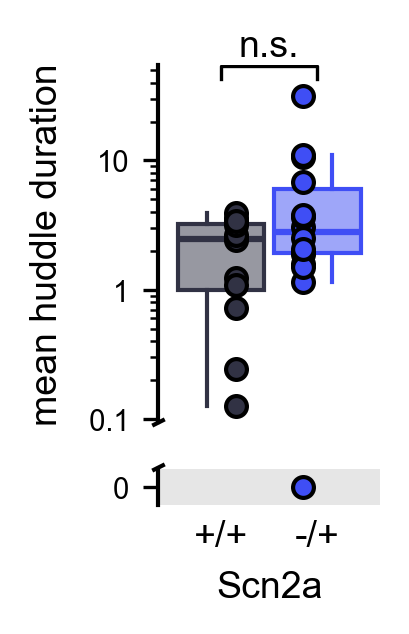

In [55]:
# ----- PLOT HUDDLE DURATION, INTRODUCTIONS, MEAN -----

# ----- FILTER DATA -----
assay = 'introduction'
assaydur = 1800
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
sums = data.groupby(by=['pair_tag','GT','sex','behavior'])['duration'].mean().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
meta = pvt.loc[:,meta].copy()
hatch=''

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

xlab = 'Scn2a'
ylab = 'mean huddle duration'
lbls = ['+/+','-/+']

# filter to relevant single behavior
i = 2
blist = [behavs[i]]
fdat = meta.copy()
fdat['duration'] = pvt.loc[:,blist].sum(axis=1)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur,hatch)

boxDotPlot_introduction_count_Huddle_female.svg
Normality test results for WT female: True by Shapiro-Wilk test, p = 0.42321123669374117
Normality test results for Het female: True by Shapiro-Wilk test, p = 0.08356784447290323
TtestResult(statistic=np.float64(0.8232106055186692), pvalue=np.float64(0.4188423884427023), df=np.float64(23.0))
boxDotPlot_introduction_count_Huddle_male.svg
Normality test results for WT male: True by Shapiro-Wilk test, p = 0.15770302498438865
Normality test results for Het male: True by Shapiro-Wilk test, p = 0.6464825608899725
TtestResult(statistic=np.float64(-1.5910244938564146), pvalue=np.float64(0.12469145629230485), df=np.float64(24.0))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


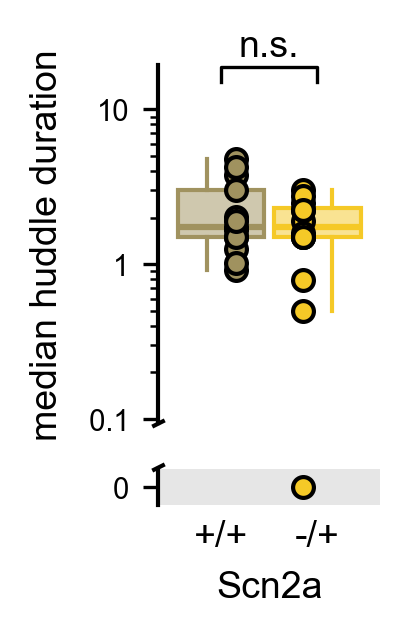

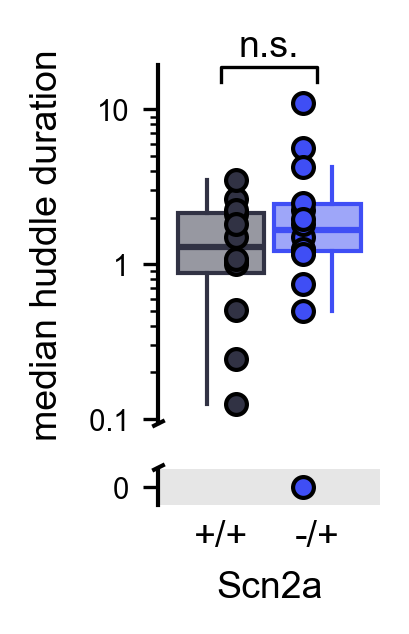

In [57]:
# ----- PLOT HUDDLE DURATION, INTRODUCTIONS, MEDIAN -----

# ----- FILTER DATA -----
assay = 'introduction'
assaydur = 1800
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
sums = data.groupby(by=['pair_tag','GT','sex','behavior'])['duration'].median().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
meta = pvt.loc[:,meta].copy()
hatch=''

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

xlab = 'Scn2a'
ylab = 'median huddle duration'
lbls = ['+/+','-/+']

# filter to relevant single behavior
i = 2
blist = [behavs[i]]
fdat = meta.copy()
fdat['duration'] = pvt.loc[:,blist].sum(axis=1)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur,hatch)

boxDotPlot_introduction_count_Huddle_female.svg
Normality test results for WT female: True by Shapiro-Wilk test, p = 0.6260965605685815
Normality test results for Het female: True by Shapiro-Wilk test, p = 0.9076692132401034
TtestResult(statistic=np.float64(0.37156315461931144), pvalue=np.float64(0.7136191593033101), df=np.float64(23.0))
boxDotPlot_introduction_count_Huddle_male.svg
Normality test results for WT male: True by Shapiro-Wilk test, p = 0.2453266251534868
Normality test results for Het male: False by Shapiro-Wilk test, p = 0.0018195168273305014
MannwhitneyuResult(statistic=np.float64(44.0), pvalue=np.float64(0.042188009531505))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


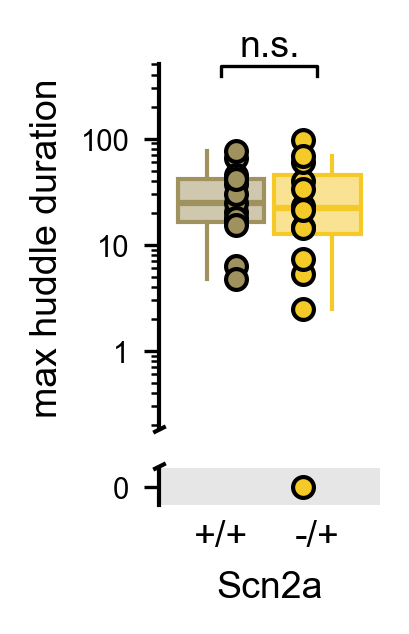

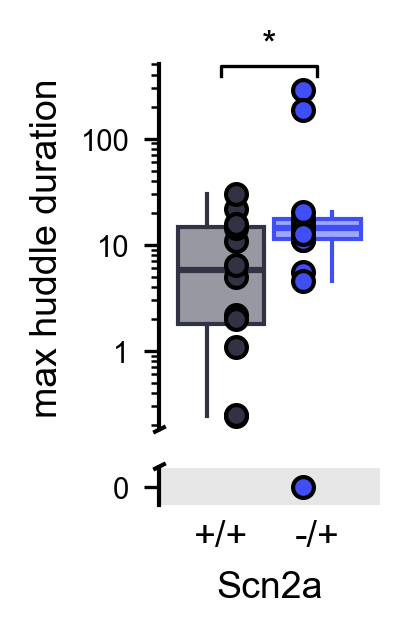

In [59]:
# ----- PLOT HUDDLE DURATION, INTRODUCTIONS, MAX -----

# ----- FILTER DATA -----
assay = 'introduction'
assaydur = 1800
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
sums = data.groupby(by=['pair_tag','GT','sex','behavior'])['duration'].max().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
meta = pvt.loc[:,meta].copy()
hatch=''

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

xlab = 'Scn2a'
ylab = 'max huddle duration'
lbls = ['+/+','-/+']

# filter to relevant single behavior
i = 2
blist = [behavs[i]]
fdat = meta.copy()
fdat['duration'] = pvt.loc[:,blist].sum(axis=1)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur,hatch)

boxDotPlot_reunion_count_Huddle_female.svg
Normality test results for WT female: True by Shapiro-Wilk test, p = 0.06155589794230682
Normality test results for Het female: True by Shapiro-Wilk test, p = 0.9694399019170566
TtestResult(statistic=np.float64(0.5749023006518981), pvalue=np.float64(0.5709388549200218), df=np.float64(23.0))
boxDotPlot_reunion_count_Huddle_male.svg
Normality test results for WT male: True by Shapiro-Wilk test, p = 0.3186170015794746
Normality test results for Het male: True by Shapiro-Wilk test, p = 0.1911483395177373
TtestResult(statistic=np.float64(-0.09993354384259634), pvalue=np.float64(0.9212271806191117), df=np.float64(24.0))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


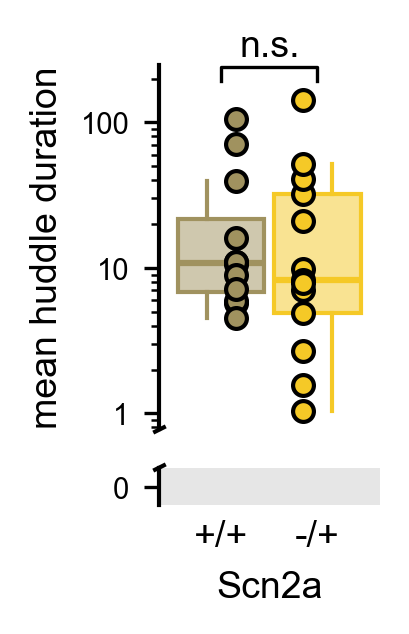

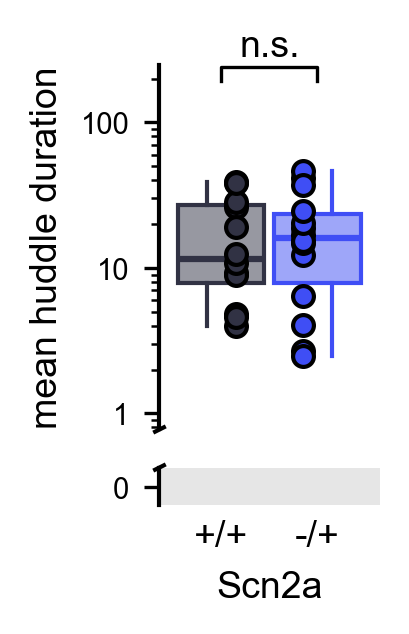

In [60]:
# ----- PLOT HUDDLE DURATION, REUNION, MEAN -----

# ----- FILTER DATA -----
assay = 'reunion'
assaydur = 1800
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
sums = data.groupby(by=['pair_tag','GT','sex','behavior'])['duration'].mean().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
meta = pvt.loc[:,meta].copy()
hatch=''

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

xlab = 'Scn2a'
ylab = 'mean huddle duration (s)'
lbls = ['+/+','-/+']

# filter to relevant single behavior
i = 2
blist = [behavs[i]]
fdat = meta.copy()
fdat['duration'] = pvt.loc[:,blist].sum(axis=1)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur,hatch)

boxDotPlot_reunion_count_Huddle_female.svg
Normality test results for WT female: True by Shapiro-Wilk test, p = 0.2879354011806169
Normality test results for Het female: True by Shapiro-Wilk test, p = 0.39851394632902176
TtestResult(statistic=np.float64(1.1696562686874339), pvalue=np.float64(0.2576340371342486), df=np.float64(17.717774827829917))
boxDotPlot_reunion_count_Huddle_male.svg
Normality test results for WT male: True by Shapiro-Wilk test, p = 0.49030723276555827
Normality test results for Het male: True by Shapiro-Wilk test, p = 0.5467599806427174
TtestResult(statistic=np.float64(0.48624095992544336), pvalue=np.float64(0.6312067580418107), df=np.float64(24.0))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


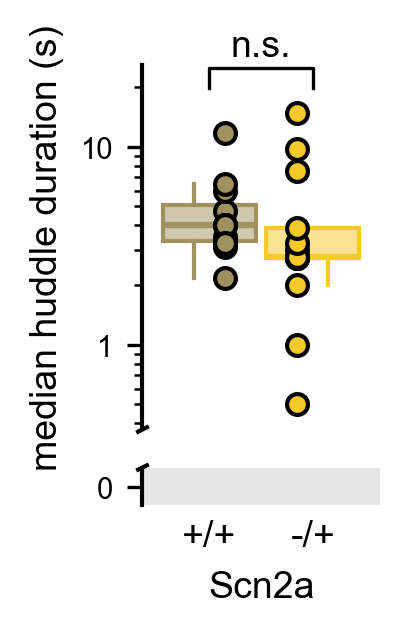

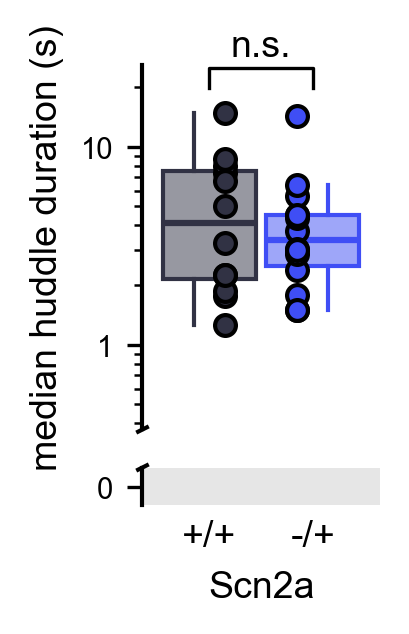

In [61]:
# ----- PLOT HUDDLE DURATION, REUNION, MEDIAN -----

# ----- FILTER DATA -----
assay = 'reunion'
assaydur = 1800
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
sums = data.groupby(by=['pair_tag','GT','sex','behavior'])['duration'].median().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
meta = pvt.loc[:,meta].copy()
hatch=''

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

xlab = 'Scn2a'
ylab = 'median huddle duration (s)'
lbls = ['+/+','-/+']

# filter to relevant single behavior
i = 2
blist = [behavs[i]]
fdat = meta.copy()
fdat['duration'] = pvt.loc[:,blist].sum(axis=1)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur,hatch)

boxDotPlot_reunion_count_Huddle_female.svg
Normality test results for WT female: True by Shapiro-Wilk test, p = 0.10179210410960116
Normality test results for Het female: True by Shapiro-Wilk test, p = 0.3138115054540772
TtestResult(statistic=np.float64(0.21350251563565595), pvalue=np.float64(0.8328162768155496), df=np.float64(23.0))
boxDotPlot_reunion_count_Huddle_male.svg
Normality test results for WT male: True by Shapiro-Wilk test, p = 0.08162678938565922
Normality test results for Het male: True by Shapiro-Wilk test, p = 0.3506291666545648
TtestResult(statistic=np.float64(-0.6308426589712891), pvalue=np.float64(0.5341053610542857), df=np.float64(24.0))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


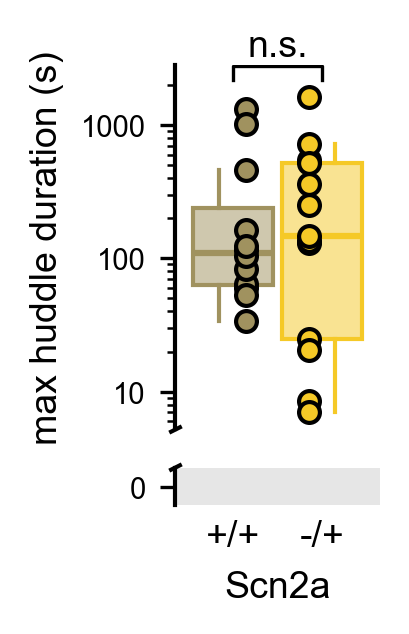

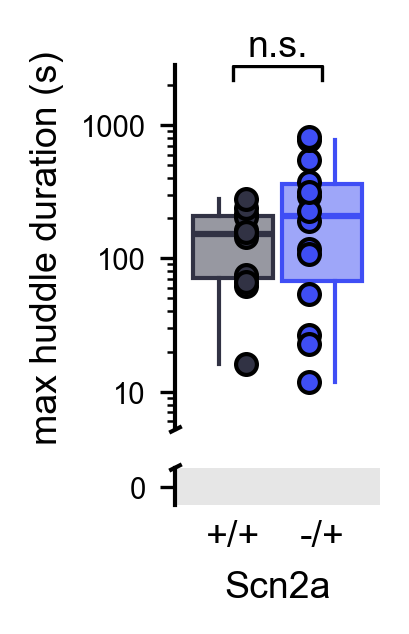

In [62]:
# ----- PLOT HUDDLE DURATION, REUNION, MAX -----

# ----- FILTER DATA -----
assay = 'reunion'
assaydur = 1800
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
sums = data.groupby(by=['pair_tag','GT','sex','behavior'])['duration'].max().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
meta = pvt.loc[:,meta].copy()
hatch=''

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

xlab = 'Scn2a'
ylab = 'max huddle duration (s)'
lbls = ['+/+','-/+']

# filter to relevant single behavior
i = 2
blist = [behavs[i]]
fdat = meta.copy()
fdat['duration'] = pvt.loc[:,blist].sum(axis=1)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur,hatch)

boxDotPlot_aggression_duration_Huddle_female.svg
Normality test results for WT female: False by Shapiro-Wilk test, p = 0.02465761361913505
Normality test results for Het female: True by Shapiro-Wilk test, p = 0.5279950899480512
MannwhitneyuResult(statistic=np.float64(67.0), pvalue=np.float64(0.9754506745843579))
boxDotPlot_aggression_duration_Huddle_male.svg
Normality test results for WT male: True by Shapiro-Wilk test, p = 0.18148247422130415
Normality test results for Het male: True by Shapiro-Wilk test, p = 0.740278926662443
TtestResult(statistic=np.float64(-0.990357601525388), pvalue=np.float64(0.3332740879985081), df=np.float64(21.0))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\2944643428.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\2944643428.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


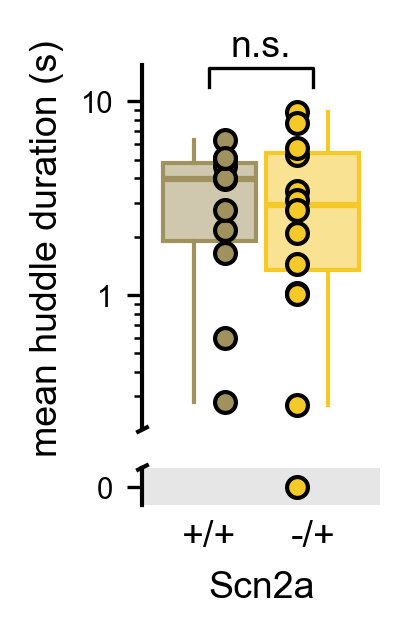

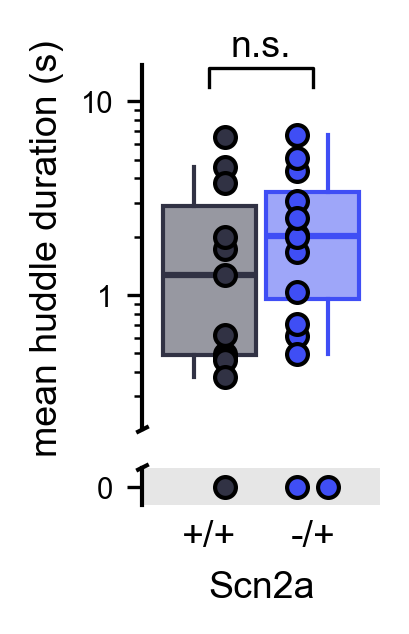

In [70]:
# ----- PLOT HUDDLE DURATION, AGGRESSION, MEAN -----

# ----- FILTER DATA -----
assay = 'aggression'
assaydur = 1200
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
sums = data.groupby(by=['pair_tag','GT','sex','behavior'])['duration'].mean().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
meta = pvt.loc[:,meta].copy()
hatch=''

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

xlab = 'Scn2a'
ylab = 'mean huddle duration (s)'
lbls = ['+/+','-/+']

# filter to relevant single behavior
i = 2
blist = [behavs[i]]
fdat = meta.copy()
fdat['duration'] = pvt.loc[:,blist].sum(axis=1)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur,hatch)

boxDotPlot_aggression_count_Huddle_female.svg
Normality test results for WT female: True by Shapiro-Wilk test, p = 0.11197952506396647
Normality test results for Het female: True by Shapiro-Wilk test, p = 0.1960712511785721
TtestResult(statistic=np.float64(0.5963239709915581), pvalue=np.float64(0.5573329037928969), df=np.float64(21.0))
boxDotPlot_aggression_count_Huddle_male.svg
Normality test results for WT male: True by Shapiro-Wilk test, p = 0.4756429874263429
Normality test results for Het male: True by Shapiro-Wilk test, p = 0.3262087466468411
TtestResult(statistic=np.float64(-0.40918648120070145), pvalue=np.float64(0.6865461177898067), df=np.float64(21.0))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


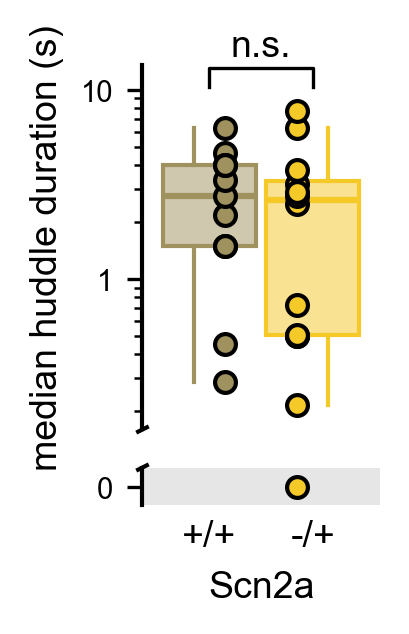

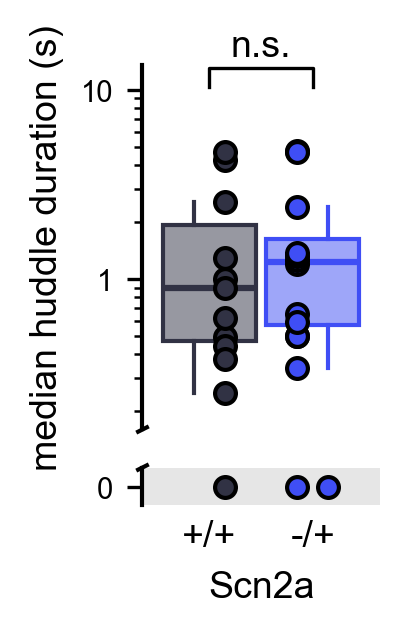

In [64]:
# ----- PLOT HUDDLE DURATION, AGGRESSION, MEDIAN -----

# ----- FILTER DATA -----
assay = 'aggression'
assaydur = 1200
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
sums = data.groupby(by=['pair_tag','GT','sex','behavior'])['duration'].median().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
meta = pvt.loc[:,meta].copy()
hatch=''

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

xlab = 'Scn2a'
ylab = 'median huddle duration (s)'
lbls = ['+/+','-/+']

# filter to relevant single behavior
i = 2
blist = [behavs[i]]
fdat = meta.copy()
fdat['duration'] = pvt.loc[:,blist].sum(axis=1)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur,hatch)

boxDotPlot_aggression_count_Huddle_female.svg
Normality test results for WT female: True by Shapiro-Wilk test, p = 0.08865462245005357
Normality test results for Het female: True by Shapiro-Wilk test, p = 0.4038062249049608
TtestResult(statistic=np.float64(-0.900333777706024), pvalue=np.float64(0.3781519758180828), df=np.float64(21.0))
boxDotPlot_aggression_count_Huddle_male.svg
Normality test results for WT male: True by Shapiro-Wilk test, p = 0.06618947328475108
Normality test results for Het male: True by Shapiro-Wilk test, p = 0.5908595485505457
TtestResult(statistic=np.float64(-1.8794794797146805), pvalue=np.float64(0.0741276626288309), df=np.float64(21.0))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\nhogl\AppData\Local\Temp\ipykernel_18468\253824349.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


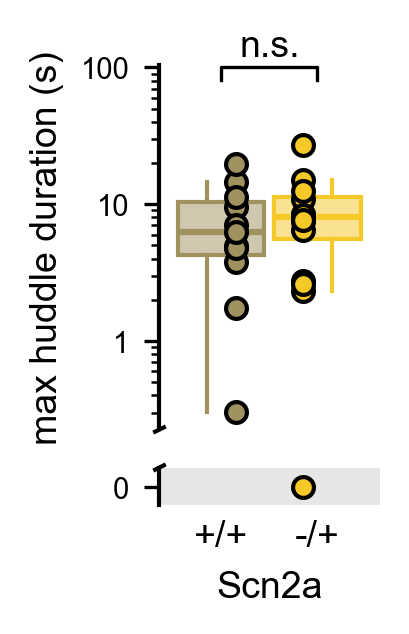

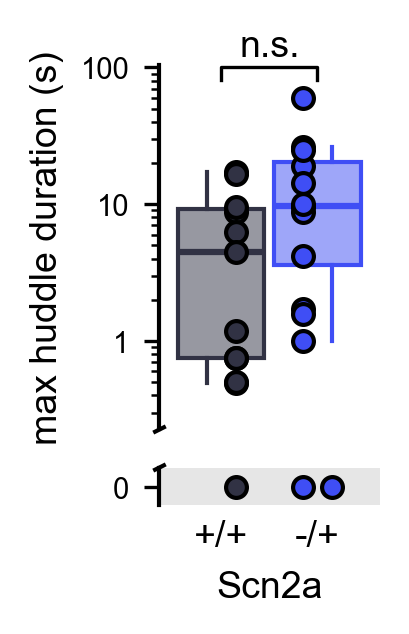

In [65]:
# ----- PLOT HUDDLE DURATION, AGGRESSION, MAX -----

# ----- FILTER DATA -----
assay = 'aggression'
assaydur = 1200
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
sums = data.groupby(by=['pair_tag','GT','sex','behavior'])['duration'].max().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
meta = pvt.loc[:,meta].copy()
hatch=''

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

xlab = 'Scn2a'
ylab = 'max huddle duration (s)'
lbls = ['+/+','-/+']

# filter to relevant single behavior
i = 2
blist = [behavs[i]]
fdat = meta.copy()
fdat['duration'] = pvt.loc[:,blist].sum(axis=1)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_MF_homecage_dotbox_plots(fdat,sexes,bstr,savefigs,printstats,lbls,assaydur,hatch)

23
27


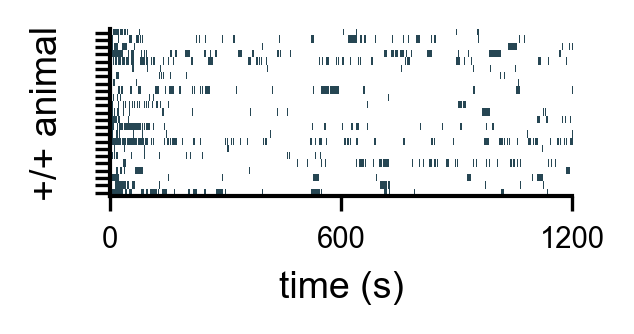

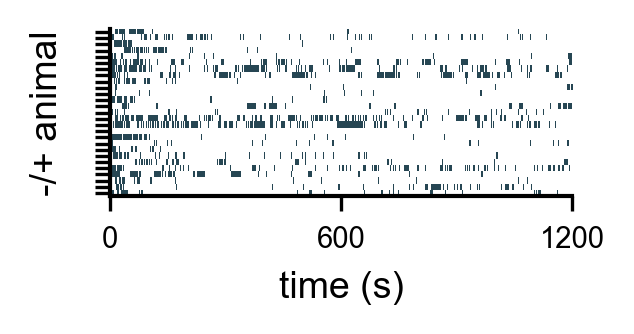

In [7]:
# ----- PLOT TIMING OF HUDDLES ACROSS ASSAYS -----

# - aggression huddles by individual
# -> make time bins and for each individual, whether that bin has huddling or not, plot a grid
# - then add investigations in another color to grid

# ----- SET ASSAY PARAMETERS -----
assay = 'aggression'
assaydur = 1200
meta = ['sex','GT','pair_tag']
gts = ['WT','Het']
tickstep = 10*60
binsz = 0.1 # seconds

# ----- PLOTTING PARAMETERS ------
# custom_colors = ['#ffffff','#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']
custom_colors = ['#ffffff', '#e76f51','#f4a261','#264653',]
cmap = ListedColormap(custom_colors)
gttxt = ['+/+','-/+']
figsz = (2,1) # total size of figure

# ----- FILTER DATA ----- !!!!!!!!

investigative = ['Sniff','Investigate']
agonistic = ['Defensive rear','Defensive strike','Strike','Tussle']
affiliative = ['Huddle']
blist = investigative+agonistic+affiliative

data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
tdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
sdat = tdat.copy()
sdat['behavior'] = sdat['behavior'].replace(investigative, ['investigative']*len(investigative))
sdat['behavior'] = sdat['behavior'].replace(agonistic,['agonistic']*len(agonistic))
sdat['behavior'] = sdat['behavior'].replace(affiliative,['affiliative']*len(affiliative))

# sums = data.groupby(by=['pair_tag','GT','sex','behavior']).duration.count().reset_index()
# pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
# meta = pvt.loc[:,meta].copy()
# hatch=''

# tdat = sdat[sdat['assay']==assay]
# binned = make_bins_from_DF(tdat,binsz,assaydur)
binned = make_bins_from_DF(sdat,binsz,assaydur)
binnedpvt = binned.pivot(index=['pair_tag','GT','sex'],columns='bins',values='data').fillna(0).reset_index()

for i,gt in enumerate(gts):
    # cmap = ListedColormap([[1,1,1], mcols[i]])

    tdf = binnedpvt[binnedpvt.GT==gt].copy().reset_index(drop=True)
    tnum = tdf.drop(labels=['pair_tag','GT','sex'],axis=1).copy().reset_index(drop=True).to_numpy()
    
    # make figure
    fig, ax = plt.subplots(figsize=figsz)

    print(tnum.shape[0])

    ax.matshow(tnum,aspect='auto',cmap=cmap)
    ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
    ax.set_yticks(np.linspace(0,tnum.shape[0]-1,tnum.shape[0]))
    ax.set_yticklabels([])
    ax.set_xticks([0,6000,12000])
    ax.set_xticklabels([0,600,1200])
    ax.set_xlabel('time (s)')
    ax.set_ylabel(f'{gttxt[i]} animal')

12
14


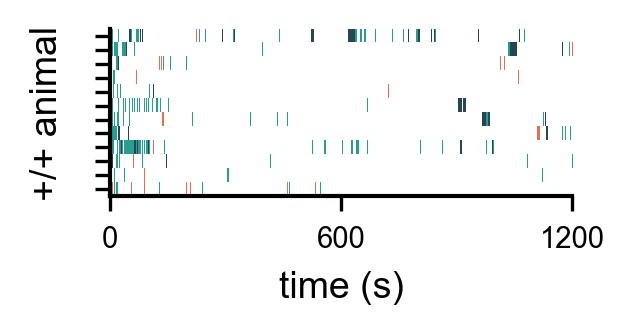

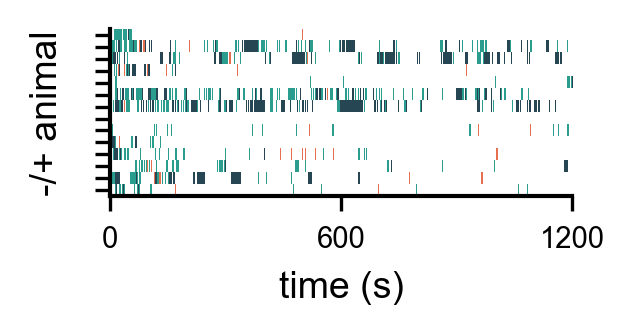

In [8]:
# ----- SET ASSAY PARAMETERS -----
assay = 'aggression'
assaydur = 1200
meta = ['sex','GT','pair_tag']
gts = ['WT','Het']
tickstep = 10*60
binsz = 0.1 # seconds
sex = 'M'

# ----- PLOTTING PARAMETERS ------
# custom_colors = ['#ffffff','#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']
# custom_colors = ['#ffffff', '#e76f51','#e9c46a','#f4a261','#264653',]
custom_colors = ['#ffffff', '#264653','#e76f51','#2a9d8f',]

cmap = ListedColormap(custom_colors)
gttxt = ['+/+','-/+']
figsz = (2,1) # total size of figure

# ----- FILTER DATA ----- !!!!!!!!

investigative = ['Sniff','Investigate']
agonistic = ['Defensive rear','Defensive strike','Strike','Tussle']
affiliative = ['Huddle']
# blist = investigative+agonistic+affiliative
blist = affiliative+investigative+agonistic

data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
data = data[data.sex=='M'].copy().reset_index(drop=True)
tdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
sdat = tdat.copy()
sdat['behavior'] = sdat['behavior'].replace(investigative, ['investigative']*len(investigative))
sdat['behavior'] = sdat['behavior'].replace(agonistic,['agonistic']*len(agonistic))
sdat['behavior'] = sdat['behavior'].replace(affiliative,['affiliative']*len(affiliative))

binlist = []

for i,behavior in enumerate(np.unique(sdat.behavior)):
    udat = sdat[sdat['behavior']==behavior].copy().reset_index(drop=True)
    binned = make_bins_from_DF(udat,binsz,assaydur)
    binned['data'] = binned['data']*(i+1)
    binlist.append(binned)

bigbinned = pd.concat(binlist)

binsums = bigbinned.groupby(by=['pair_tag','bins','GT'])['data'].sum().reset_index()
binnedpvt = binsums.pivot(index=['pair_tag','GT'],columns='bins',values='data').fillna(0).reset_index()

for i,gt in enumerate(gts):
    tdf = binnedpvt[binnedpvt.GT==gt].copy().reset_index(drop=True)
    tnum = tdf.drop(labels=['pair_tag','GT'],axis=1).copy().reset_index(drop=True).to_numpy()
    
    # make figure
    fig, ax = plt.subplots(figsize=figsz)

    print(tnum.shape[0])

    ax.matshow(tnum,aspect='auto',cmap=cmap)
    ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
    ax.set_yticks(np.linspace(0,tnum.shape[0]-1,tnum.shape[0]))
    ax.set_yticklabels([])
    ax.set_xticks([0,6000,12000])
    ax.set_xticklabels([0,600,1200])
    ax.set_xlabel('time (s)')
    ax.set_ylabel(f'{gttxt[i]} animal')

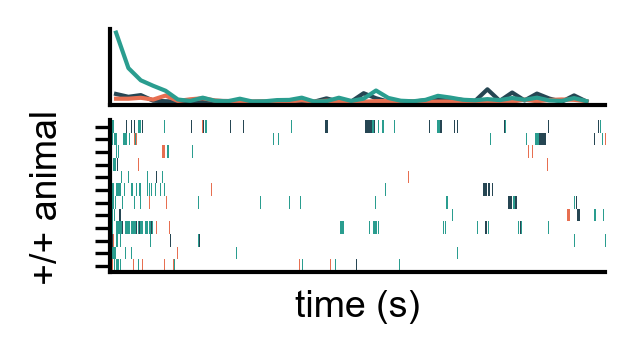

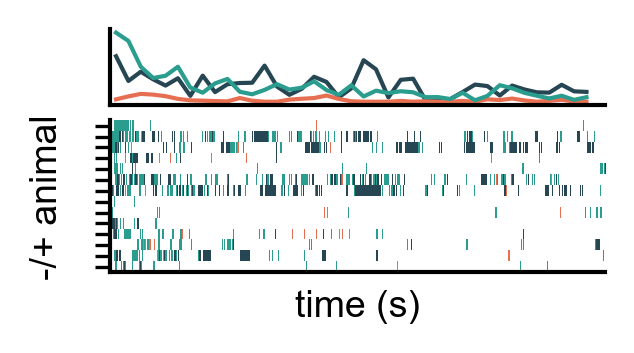

In [12]:
# ----- PLOT RASTERS WITH MARGINAL HISTOGRAM -----

# ----- SET ASSAY PARAMETERS -----
assay = 'aggression'
assaydur = 1200
meta = ['sex','GT','pair_tag']
gts = ['WT','Het']
tickstep = 10*60
binsz = 0.1 # seconds
sex = 'M'
bigbinsz = 30 # seconds
histbins = np.linspace(0,assaydur,int(assaydur/bigbinsz)+1)[:-1]

# ----- PLOTTING PARAMETERS ------
# custom_colors = ['#ffffff','#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']
# custom_colors = ['#ffffff', '#e76f51','#e9c46a','#f4a261','#264653',]
custom_colors = ['#ffffff', '#264653','#e76f51','#2a9d8f',]

cmap = ListedColormap(custom_colors)
gttxt = ['+/+','-/+']
figsz = (2,1) # total size of figure

# ----- FILTER DATA ----- !!!!!!!!

investigative = ['Sniff','Investigate']
agonistic = ['Defensive rear','Defensive strike','Strike','Tussle']
affiliative = ['Huddle']
# blist = investigative+agonistic+affiliative
blist = affiliative+investigative+agonistic

data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
data = data[data.sex=='M'].copy().reset_index(drop=True)
tdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
sdat = tdat.copy()
sdat['behavior'] = sdat['behavior'].replace(investigative, ['investigative']*len(investigative))
sdat['behavior'] = sdat['behavior'].replace(agonistic,['agonistic']*len(agonistic))
sdat['behavior'] = sdat['behavior'].replace(affiliative,['affiliative']*len(affiliative))

binlist = []

for i,behavior in enumerate(np.unique(sdat.behavior)):
    udat = sdat[sdat['behavior']==behavior].copy().reset_index(drop=True)
    binned = make_bins_from_DF(udat,binsz,assaydur)
    binned['data'] = binned['data']*(i+1)
    binlist.append(binned)

bigbinned = pd.concat(binlist)

binsums = bigbinned.groupby(by=['pair_tag','bins','GT'])['data'].sum().reset_index()
binnedpvt = binsums.pivot(index=['pair_tag','GT'],columns='bins',values='data').fillna(0).reset_index()

hists = []

for i,gt in enumerate(gts):
    tdf = binnedpvt[binnedpvt.GT==gt].copy().reset_index(drop=True)
    tnum = tdf.drop(labels=['pair_tag','GT'],axis=1).copy().reset_index(drop=True).to_numpy()

    thists = []
    plothists = []

    # separate by behavior
    for j,val in enumerate(np.unique(binsums.data)[1:]):
        bdf = binsums[np.logical_and(binsums.GT==gt,binsums.data==val)].copy().reset_index(drop=True)
        bdf['data']=bdf['data']/val
        histdf = bdf.groupby(pd.cut(bdf['bins'],bins=histbins,right=False),observed=False).count().drop(['bins','GT','pair_tag'],axis=1)
        histdf['data'] = ((histdf['data']/bigbinsz)*binsz)/len(np.unique(bdf.pair_tag))
        histdf = histdf.transpose()
        histplot = histdf.copy()
        histdf['GT']=gt
        histdf['behavior'] = np.unique(sdat.behavior)[j]
        thists.append(histdf)
        plothists.append(histplot)

    hists.append(pd.concat(thists))
        
        # calculate histogram of each behavior
    # filter by number
    # recombine bins
    
    # make figure
    # fig, ax = plt.subplots(figsize=figsz)
    fig = plt.figure(layout='constrained',figsize=figsz)
    ax = fig.add_subplot()
    ax_histx = ax.inset_axes([0, 1.1, 1, 0.5], sharex=ax)

    ax.matshow(tnum,aspect='auto',cmap=cmap)
    ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
    ax.set_yticks(np.linspace(0,tnum.shape[0]-1,tnum.shape[0]))
    ax.set_yticklabels([])
    ax.set_xticks([0,6000,12000])
    ax.set_xticklabels([0,600,1200])
    ax.set_xlabel('time (s)')
    ax.set_ylabel(f'{gttxt[i]} animal')

    for j,val in enumerate(np.unique(binsums.data)[1:]):
        ax_histx.plot((histbins[:-1]+bigbinsz*0.5)/binsz,plothists[j].loc['data'],color=custom_colors[j+1],lw=1)

    ax_histx.set_yticks([])
    ax_histx.set_xticks([])



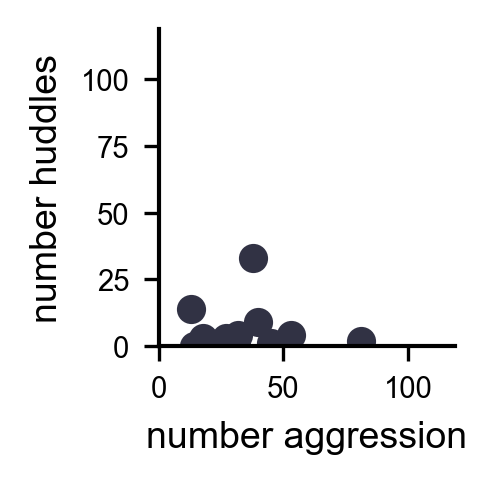

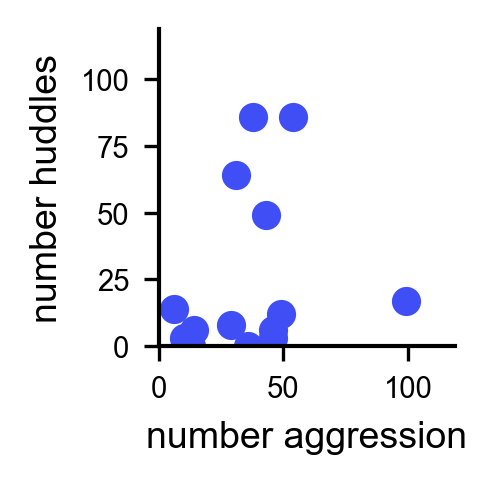

In [57]:
# ----- LATENCY FROM AGGRESSION RECEIPT TO NEXT HUDDLE -----

# ----- SET ASSAY PARAMETERS -----
assay = 'aggression'
assaydur = 1200
meta = ['sex','GT','pair_tag']
gts = ['WT','Het']
sex = 'M'
gttxt = ['+/+','-/+']
blist = ['Aggression receipt','Huddle']
figsz = (1.5,1.5)

data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
data = data[data.sex=='M'].copy().reset_index(drop=True)
allbehav = np.unique(data['behavior'])
# print(allbehav)
tdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True) # filter to specified behaviors
counts = tdat.groupby(by=['pair_tag','GT','behavior'])['start_time'].count().reset_index()
# okay the counts do actually look promising, move forward

# plot counts
countspivot = pd.pivot(counts, index=['pair_tag','GT'], columns='behavior', values='start_time').fillna(0).reset_index()
axmax = np.max([np.max(countspivot['Huddle']),np.max(countspivot['Aggression receipt'])])*1.2
for gt,col in zip(gts,mcols):
    tdf = countspivot[countspivot['GT']==gt]
    fig = plt.figure(layout='constrained',figsize=figsz)
    ax = fig.add_subplot()
    ax.scatter(tdf['Aggression receipt'],tdf['Huddle'],color=col)
    ax.set_xlabel('number aggression')
    ax.set_ylabel('number huddles')
    ax.set_xlim([0, axmax])
    ax.set_ylim([0, axmax])  

# --- Calculate latency from aggression receipt to huddle ---
# for each pair
allpairs = np.unique(tdat['pair_tag'])
priortimes_allpairs = []
for pair in allpairs:
    tdf = tdat[tdat['pair_tag']==pair].copy().reset_index(drop=True)
    tdfh = tdf[tdf['behavior']=='Huddle'].copy().reset_index(drop=True)
    tdfa = tdf[tdf['behavior']=='Aggression receipt'].copy().reset_index(drop=True)
    priortimes = []
    for start_time in tdfh['start_time']:
        priors = tdfa['start_time'][tdfa['start_time']<start_time]
        if len(priors)>0:
            priortimes.append(start_time-np.max(priors))
        else:
            priortimes.append(np.nan)
    priortimes_allpairs.append(priortimes)
    # for each huddle
        # find max time of aggression receipt before huddle
        # append to priortimes

In [70]:
# --- Calculate latency from aggression receipt to huddle ---
# for each pair
allpairs = np.unique(tdat['pair_tag'])
priortimes_allpairs = []
pairtags = []
pairtagslong = []
GTs = []
GTslong = []
priortimeslong = []
for pair in allpairs:
    tdf = tdat[tdat['pair_tag']==pair].copy().reset_index(drop=True)
    tdfh = tdf[tdf['behavior']=='Huddle'].copy().reset_index(drop=True)
    tdfa = tdf[tdf['behavior']=='Aggression receipt'].copy().reset_index(drop=True)
    pairtags.append(pair)
    gt = np.unique(tdf['GT'])[0]
    GTs.append(gt)
    priortimes = []
    for start_time in tdfh['start_time']:
        priors = tdfa['start_time'][tdfa['start_time']<start_time]
        if len(priors)>0:
            priortimes.append(start_time-np.max(priors))
        else:
            priortimes.append(np.nan)
    nrtimes = len(priortimes)
    priortimes_allpairs.append(priortimes)
    for i,time in enumerate(priortimes):
        priortimeslong.append(time)
        GTslong.append(gt)
        pairtagslong.append(pair)

data = {'pairtag':pairtagslong,'GT':GTslong,'latency':priortimeslong}    
df = pd.DataFrame(data=data)

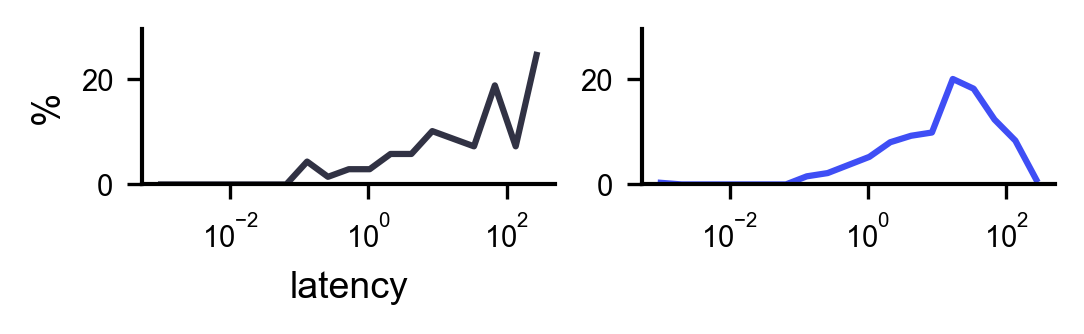

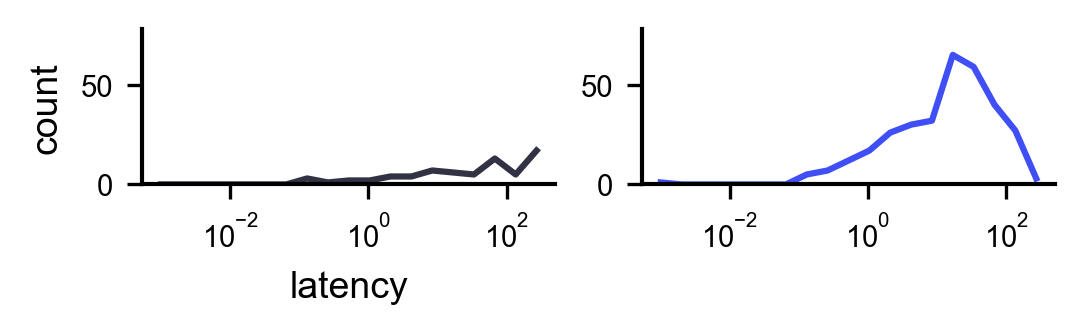

In [80]:
# plot distributions of latencies

gts = ['WT','Het']

minval = np.min(df.latency)
maxval = np.max(df.latency)
bins = np.logspace(np.log10(minval),np.log10(maxval),20)
hists = []

# make figure
figsz = (3.5,1) # total size of figure
fig, axs = plt.subplots(1,2,figsize=figsz)

mxbin = 0

for i,gt in enumerate(gts):
    gdf = df[df['GT']==gt].copy().reset_index(drop=True)
    tcol = mcols[i]
    adf = gdf
    thist,rebins = np.histogram(adf['latency'],bins=bins)
    thist = 100*thist/np.sum(thist)
    hists.append(thist)
    ax = axs[i]
    ax.plot(bins[0:-1],thist,color=tcol)
    ax.set_xscale('log')
    mxbin = np.max([np.max(thist),mxbin])
    if i==0:
        ax.set_xlabel('latency')
        ax.set_ylabel('%')

for i,gt in enumerate(gts):
    ax = axs[i]
    ax.set_ylim([0,mxbin*1.2])

# make figure
figsz = (3.5,1) # total size of figure
fig, axs = plt.subplots(1,2,figsize=figsz)

mxbin = 0

for i,gt in enumerate(gts):
    gdf = df[df['GT']==gt].copy().reset_index(drop=True)
    tcol = mcols[i]
    adf = gdf
    thist,rebins = np.histogram(adf['latency'],bins=bins)
    hists.append(thist)
    ax = axs[i]
    ax.plot(bins[0:-1],thist,color=tcol)
    ax.set_xscale('log')
    mxbin = np.max([np.max(thist),mxbin])
    if i==0:
        ax.set_xlabel('latency')
        ax.set_ylabel('count')

for i,gt in enumerate(gts):
    ax = axs[i]
    ax.set_ylim([0,mxbin*1.2])

C:\Users\Nerissa\AppData\Local\Temp\ipykernel_4304\4006936640.py:58: RuntimeWarning: Mean of empty slice
  means = df.groupby(by=['pairtag','GT','sex'])['latency'].apply(lambda x: np.nanmean(x)).reset_index()
C:\Users\Nerissa\AppData\Local\Temp\ipykernel_4304\2475936185.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\Nerissa\AppData\Local\Temp\ipykernel_4304\2475936185.py:223: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


boxDotPlot_aggression_duration_aggression-huddle-latencyfemale.svg
Normality test results for WT female: True by Shapiro-Wilk test, p = 0.8691939115524292
Normality test results for Het female: True by Shapiro-Wilk test, p = 0.32486388087272644
Ttest_indResult(statistic=0.9212626157533812, pvalue=0.37860282638808174)
boxDotPlot_aggression_duration_aggression-huddle-latencymale.svg
Normality test results for WT male: False by Shapiro-Wilk test, p = 0.012146164663136005
Normality test results for Het male: False by Shapiro-Wilk test, p = 0.03512804955244064
MannwhitneyuResult(statistic=82.0, pvalue=0.1562877116676799)


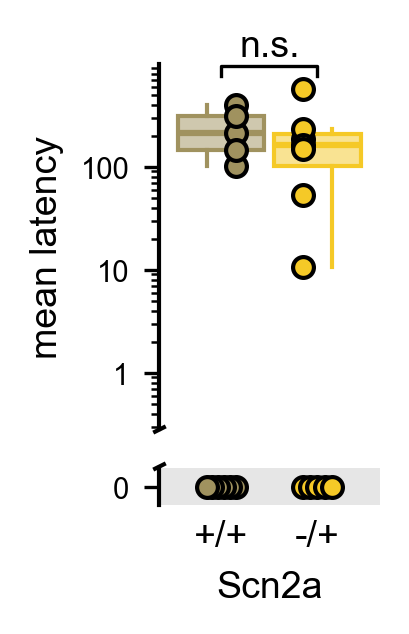

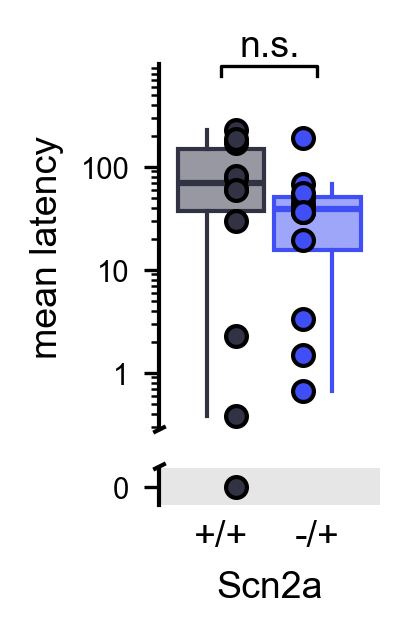

In [101]:
# plot mean latency per individual

# ----- SET ASSAY PARAMETERS -----
assay = 'aggression'
assaydur = 1200
meta = ['sex','GT','pair_tag']
gts = ['WT','Het']
gttxt = ['+/+','-/+']
blist = ['Aggression receipt','Huddle']
figsz = (1.5,1.5)
sexes = ['female','male']
bstr = 'aggression-huddle-latency'
hatch = ''
savefigs = False
xlab = 'Scn2a'
ylab = 'mean latency'

data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
allbehav = np.unique(data['behavior'])
tdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True) # filter to specified behaviors

# --- Calculate latency from aggression receipt to huddle ---
# for each pair
allpairs = np.unique(tdat['pair_tag'])
priortimes_allpairs = []
pairtags = []
pairtagslong = []
GTs = []
GTslong = []
priortimeslong = []
sexlong = []
for pair in allpairs:
    tdf = tdat[tdat['pair_tag']==pair].copy().reset_index(drop=True)
    tdfh = tdf[tdf['behavior']=='Huddle'].copy().reset_index(drop=True)
    tdfa = tdf[tdf['behavior']=='Aggression receipt'].copy().reset_index(drop=True)
    pairtags.append(pair)
    gt = np.unique(tdf['GT'])[0]
    sex = np.unique(tdf['sex'])[0]
    GTs.append(gt)
    priortimes = []
    for start_time in tdfh['start_time']:
        priors = tdfa['start_time'][tdfa['start_time']<start_time]
        if len(priors)>0:
            priortimes.append(start_time-np.max(priors))
        else:
            priortimes.append(np.nan)
    nrtimes = len(priortimes)
    priortimes_allpairs.append(priortimes)
    for i,time in enumerate(priortimes):
        priortimeslong.append(time)
        GTslong.append(gt)
        pairtagslong.append(pair)
        sexlong.append(sex)

data = {'pairtag':pairtagslong,'GT':GTslong,'sex':sexlong,'latency':priortimeslong}    
df = pd.DataFrame(data=data)

means = df.groupby(by=['pairtag','GT','sex'])['latency'].apply(lambda x: np.nanmean(x)).reset_index()
means = means.fillna(0)

fsums = means.copy().rename(columns={"latency": "duration"})

make_MF_homecage_dotbox_plots(fsums,sexes,bstr,savefigs,printstats,lbls,assaydur,hatch)

In [93]:
fsums

,pairtag,GT,sex,duration
0,Pair1,Het,F,0.000000
1,Pair15,Het,F,185.396533
2,Pair16,WT,F,0.000000
3,Pair17,Het,M,3.291000
4,Pair18,WT,M,171.737303
5,Pair19,WT,M,227.280667
6,Pair2,WT,F,101.212500
7,Pair21,Het,F,53.444500
8,Pair22,Het,F,230.597000
9,Pair23,Het,F,161.782000
